# Explaining a Relational Deep Learning model

This notebook is the entry point to **RDLExplain**. It takes a GNN already trained on a
relational database and asks: *which parts of the database does this model actually rely on?*

The answer is a **database view** — a query over the schema, not a heatmap over the graph.
We compute two of the three explanation languages from the paper:

| Language | Question it answers | Mask |
|---|---|---|
| `Projection` | Which **columns** matter? | one weight per (table, column) |
| `FKJoin` | Which **foreign-key joins** matter? | one weight per FK relationship |

For each we report **deviation from determinacy (devΔ)** — the paper's quality metric.
devΔ perturbs everything the explanation does *not* cover and measures how much the
model's predictions move. **Low devΔ means the explanation suffices to determine the
model's behaviour.** It is label-free: it compares the model against itself, never
against ground truth.

Model: `rel-f1 / driver-dnf` — predict whether a Formula 1 driver fails to finish a race.
This is task D1T1 in the paper.

> Reference: Rissaki, Fountalis, Gatterbauer, Kimelfeld.
> *Database Views as Explanations for Relational Deep Learning.* PVLDB 19(7), 2026.

## Setup

Download the `rel-f1/driver-dnf` bundle (~25 MB; see the README for the link) and unzip it
so that the layout is:

```
artifacts/
└── rel-f1/driver-dnf/
    ├── manifest.json          architecture + how to verify it
    ├── data.pt                the constructed graph
    ├── col_stats_dict.pt
    ├── model_state_dict.pth   the trained model
    └── inference_results/     the predictions it produced
```

The artifact root is found automatically by searching upward for an `artifacts/`
directory, so this works unchanged from the repository root or from `notebooks/`.
Set `RDL_EXPLAIN_DATA` only to point somewhere else.

In [11]:
import os

# os.environ["RDL_EXPLAIN_DATA"] = "/path/to/artifacts"   # default: ./artifacts

import torch
import pandas as pd
import matplotlib.pyplot as plt

from rdl_explain.artifacts import load_bundle, load_explanation_task
from rdl_explain.explain.explainer import RDLExplainer
from rdl_explain.explain.masks import discretize_mask, explanation_size, DEFAULT_DELTA
from rdl_explain.explain.viz import plot_mask_importances, draw_schema_with_masks

BUNDLE = "rel-f1/driver-dnf"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Mask learning is stochastic; fix the seed so the notebook is reproducible.
torch.manual_seed(0)

# Explaining all ~11k training instances is unnecessary for a demo. The paper uses
# a class-balanced sample of 100 instances for mask learning;
N_INSTANCES = 100
N_EPOCHS = 250

print("device:", DEVICE)

device: cuda


## 1. Load the model — and verify it

Most of a model's architecture cannot be recovered from its weights. The message
aggregation (`sum` vs `mean`), the sampling fanouts and the feature-encoder depth have no
parameters of their own, so **a wrong value still loads without error** and produces a
model that runs and is wrong.

That failure is invisible downstream: a broken model still yields explanations that look
entirely reasonable. So `load_bundle` re-runs inference and checks it reproduces the
predictions the trained model itself wrote, before handing anything back. If this cell
prints a correlation, the model is the one the paper trained.

In [12]:
model, data, col_stats_dict, config, manifest = load_bundle(BUNDLE, device=DEVICE)

print("\narchitecture (from manifest.json):")
for k, v in manifest["model"].items():
    if k != "state_dict":
        print(f"  {k:16s} {v}")
print(f"\ngraph: {len(data.node_types)} tables, {len(data.edge_types)} FK edge types")

[rel-f1/driver-dnf] checkpoint verified against test predictions (corr = 0.99984, max|diff| = 4.84e-01)

architecture (from manifest.json):
  aggr             mean
  norm             batch_norm
  num_layers       3
  channels         32
  out_channels     1
  encoder_layers   2
  fanouts          [64, 32, 16]

graph: 9 tables, 26 FK edge types


## 2. Build the explanation task

We explain the **model**, not the labels. The explanation task replaces the ground-truth
target with the model's own predictions, so everything below measures agreement with the
model's behaviour. 

In [13]:
explanation_task = load_explanation_task(
    BUNDLE, explanation_target_type="soft", subsample_per_split=N_INSTANCES
)
print("explaining", len(explanation_task.train_table.df), "instances")
print("target column:", explanation_task.target_col, "(the model's own soft predictions)")

explainer = RDLExplainer(config, model, data, explanation_task)

explaining 100 instances
target column: processed_output (the model's own soft predictions)


## 3. `Projection` — which columns does the model use?

We learn one continuous weight per `(table, column)`, optimised so that masking the
low-weight columns barely changes the model's predictions. Columns are "masked" by
permuting their values across rows, which destroys the information they carry while
keeping the data distribution realistic (paper, Section 4.2).

In [14]:
column_mask, _, column_metrics = explainer.learn_masks(
    explanation_type="column",
    elimination_strategy="permutation_joint",
    eps=0.01, n_epochs=N_EPOCHS, lr=0.05,
)
print(f"learned {len(column_mask)} column weights in {column_metrics['time']:.0f}s")

Epoch 0/250: Loss 0.8454133541030328 - Task Loss 0.3954405159396569 - Regularization 44.997283935546875 - Time-per-epoch 0.85s
Epoch 25/250: Loss 0.8452015134860731 - Task Loss 0.39530294271008726 - Regularization 44.9898567199707 - Time-per-epoch 0.85s
Epoch 50/250: Loss 0.8447700230911505 - Task Loss 0.3953369347885382 - Regularization 44.94330978393555 - Time-per-epoch 0.84s
Epoch 75/250: Loss 0.8401891633031353 - Task Loss 0.39532417497610894 - Regularization 44.48649978637695 - Time-per-epoch 0.84s
Epoch 100/250: Loss 0.787657051900997 - Task Loss 0.3960795994798086 - Regularization 39.157745361328125 - Time-per-epoch 0.84s
Epoch 125/250: Loss 0.6015170774908388 - Task Loss 0.42091737310603505 - Regularization 18.05997085571289 - Time-per-epoch 0.84s
Epoch 150/250: Loss 0.5247491195234801 - Task Loss 0.4217745333346869 - Regularization 10.29745864868164 - Time-per-epoch 0.84s
Epoch 175/250: Loss 0.512189021142301 - Task Loss 0.4249763393719763 - Regularization 8.721268653869629 - 

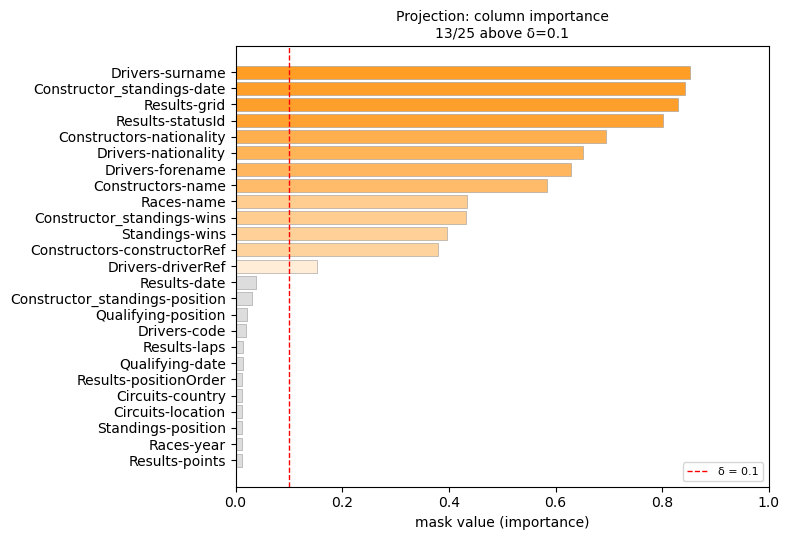

In [15]:
plot_mask_importances(column_mask, delta=DEFAULT_DELTA, top_k=25,
                      title="Projection: column importance")
plt.show()

## 4. Discretise, and measure devΔ

The learned mask is continuous; an *explanation* is discrete. We threshold at
δ = 0.1 (paper, Section 5.2) to get the set of columns in the explanation — its size is the
paper's explanation size *k*.

Then we measure devΔ: perturb every column **outside** the explanation and see how far the
model's predictions move. Near zero means the retained columns are enough to determine the
model's behaviour.

In [16]:
column_hard = discretize_mask(column_mask, delta=DEFAULT_DELTA)
k_columns = explanation_size(column_hard)
print(f"explanation size k = {k_columns} of {len(column_hard)} columns\n")
print("columns in the explanation:")
for key, keep in column_hard.items():
    if bool(keep.any()):
        print(f"   {key[0]}.{key[1]}")

column_dev, column_sem, *_ = explainer.estimate_devdelta(
    mask=column_hard, explanation_type="column",
    perturbation_strategy="permutation_joint", num_samples=5,
)
print(f"\ndevDelta = {column_dev:.4f} +/- {column_sem:.4f}")

explanation size k = 13 of 45 columns

columns in the explanation:
   Drivers.driverRef
   Drivers.forename
   Drivers.nationality
   Drivers.surname
   Results.grid
   Results.statusId
   Standings.wins
   Races.name
   Constructors.constructorRef
   Constructors.name
   Constructors.nationality
   Constructor_standings.wins
   Constructor_standings.date



devDelta = 0.0222 +/- 0.0009


## 5. `FKJoin` — which joins does the model use?

The same procedure over foreign-key relationships. Here masking means shuffling the
foreign-key assignments, which destroys *which* rows are linked while preserving how many
links exist. A join with low importance is one the model's predictions do not depend on.

In [ ]:
fkjoin_mask, _, fkjoin_metrics = explainer.learn_masks(
    explanation_type="fkpk",
    elimination_strategy="zero",
    eps=0.001, n_epochs=N_EPOCHS, lr=0.05,
)
print(f"learned {len(fkjoin_mask)} join weights in {fkjoin_metrics['time']:.0f}s")

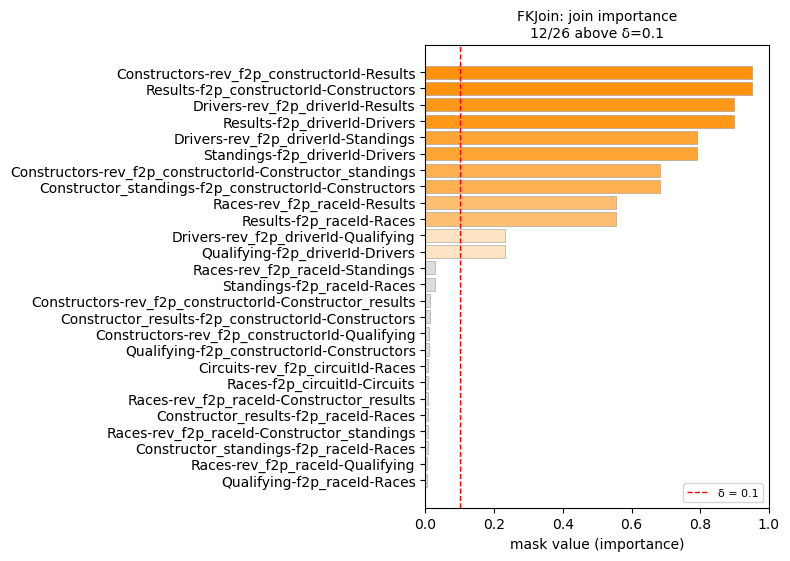

In [18]:
plot_mask_importances(fkjoin_mask, delta=DEFAULT_DELTA,
                      title="FKJoin: join importance")
plt.show()

In [19]:
fkjoin_hard = discretize_mask(fkjoin_mask, delta=DEFAULT_DELTA)
k_joins = explanation_size(fkjoin_hard)
print(f"explanation size k = {k_joins} of {len(fkjoin_hard)} join directions\n")

fkjoin_dev, fkjoin_sem, *_ = explainer.estimate_devdelta(
    mask=fkjoin_hard, explanation_type="fkpk",
    perturbation_strategy="foreign_key_uniform_random", num_samples=5,
)
print(f"devDelta = {fkjoin_dev:.4f} +/- {fkjoin_sem:.4f}")

explanation size k = 12 of 26 join directions



devDelta = 0.0111 +/- 0.0002


## 6. The explanation as a database view

Bar charts rank elements; this shows what the two explanations mean together — shaded
columns are the `Projection` view, weighted arrows the `FKJoin` view, over the actual
schema. Tables beyond the model's receptive field are dimmed.

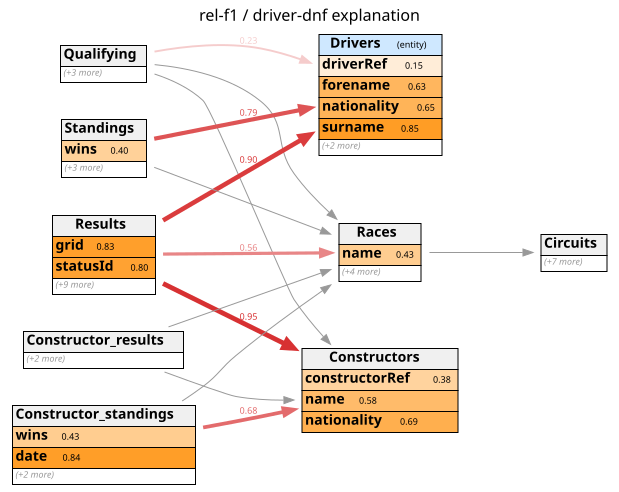

In [20]:
draw_schema_with_masks(
    data, entity_table=manifest["predictions"]["entity_table"], view="flat",
    column_mask=column_mask, fkpk_mask=fkjoin_mask,
    num_layers=config.gnn_layers, delta=DEFAULT_DELTA,
    title="rel-f1 / driver-dnf explanation",
)

## 7. Summary

In [21]:
print(f"{'language':12s} {'k':>6s} {'of':>6s} {'devDelta':>12s} {'time (s)':>10s}")
print("-" * 50)
print(f"{'Projection':12s} {k_columns:6d} {len(column_hard):6d} "
      f"{column_dev:12.4f} {column_metrics['time']:10.0f}")
print(f"{'FKJoin':12s} {k_joins:6d} {len(fkjoin_hard):6d} "
      f"{fkjoin_dev:12.4f} {fkjoin_metrics['time']:10.0f}")

language          k     of     devDelta   time (s)
--------------------------------------------------
Projection       13     45       0.0222        211
FKJoin           12     26       0.0111        122


### How to read this

**devΔ is the measurement, the column names are the finding.** A low devΔ says the
retained elements determine the model's predictions.
The identity of those elements is what tells you something about the model.

There is a trade-off between devΔ and explanation size *k*, explored in Figure 6 of the
paper: lowering δ retains more elements and drives devΔ down, at the cost of a larger,
less digestible explanation. Re-run the discretisation with a different `delta` to see it.

### Next

- `02_case_study_synthetic.ipynb` — a toy database with a known ground truth, where you
  can check the recovered explanation against the rule that generated the labels.
- `03_case_study_clinical_trials.ipynb` — the paper's case study: using all three
  languages, including `Selection`, to diagnose data leakage in a clinical-trials database.